In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")

from warnings import simplefilter

simplefilter(action='ignore', category=FutureWarning)

In [2]:
train = pd.read_csv(r"C:\Users\shafaat hussain\Desktop\aiml\Loan Prediction\Loan Train.csv")
test=pd.read_csv(r"C:\Users\shafaat hussain\Desktop\aiml\Loan Prediction\Loan Test.csv")

In [3]:
train_original=train.copy()
test_original=test.copy()

In [4]:
#EDA starts here
train.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [5]:
train.shape

(614, 13)

In [6]:
test.shape

(367, 12)

In [7]:
#checking hoe many loan status are there(614 or not)
train['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [8]:
train['Loan_Status'].value_counts(normalize=True)

Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

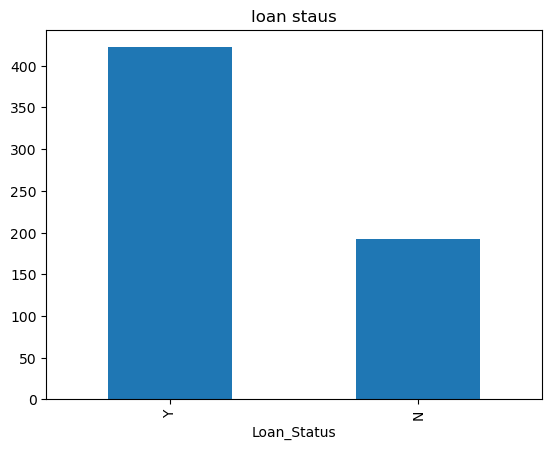

In [9]:
train['Loan_Status'].value_counts().plot.bar(title='loan staus')
plt.show()

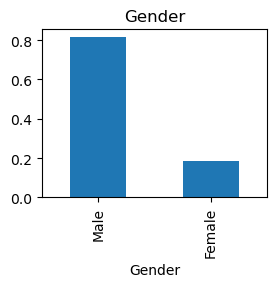

In [10]:
plt.subplot(222)
train['Gender'].value_counts(normalize='True').plot.bar(title='Gender')
plt.show()

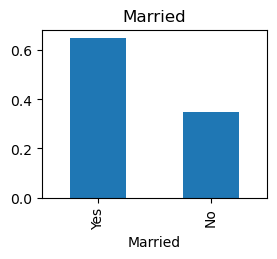

In [11]:
plt.subplot(222)
train['Married'].value_counts(normalize='True').plot.bar(title='Married')
plt.show()

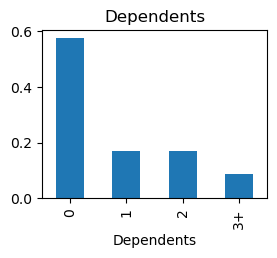

In [12]:
plt.subplot(222)
train['Dependents'].value_counts(normalize='True').plot.bar(title='Dependents')
plt.show()

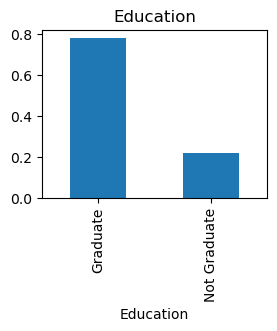

In [13]:
plt.subplot(222)
train['Education'].value_counts(normalize='True').plot.bar(title='Education')
plt.show()

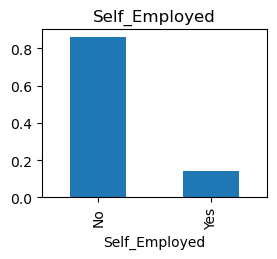

In [14]:
plt.subplot(222)
train['Self_Employed'].value_counts(normalize='True').plot.bar(title='Self_Employed')
plt.show()

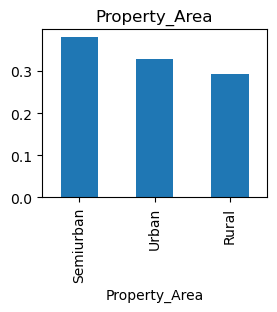

In [15]:
plt.subplot(222)
train['Property_Area'].value_counts(normalize='True').plot.bar(title='Property_Area')
plt.show()

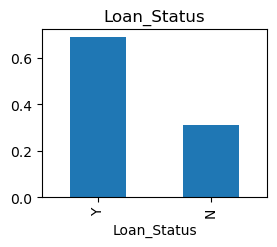

In [16]:
plt.subplot(222)
train['Loan_Status'].value_counts(normalize='True').plot.bar(title='Loan_Status')
plt.show()

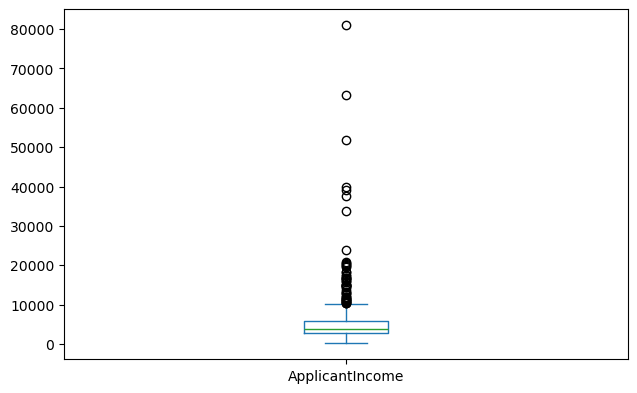

In [17]:
plt.subplot(222)
train['ApplicantIncome'].plot.box(figsize=(16,10))
plt.show()

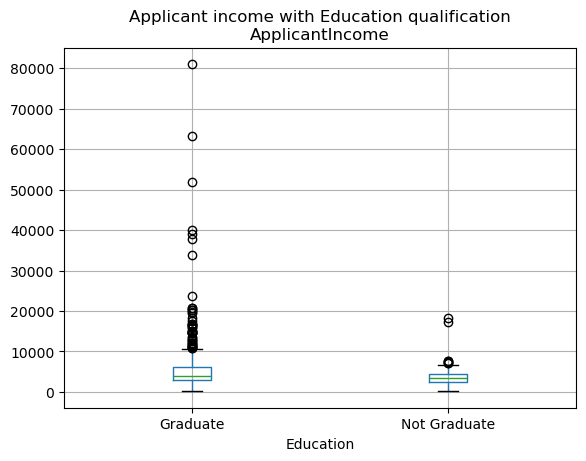

In [18]:
train.boxplot(column='ApplicantIncome', by = 'Education')
plt.suptitle("Applicant income with Education qualification")
plt.show()

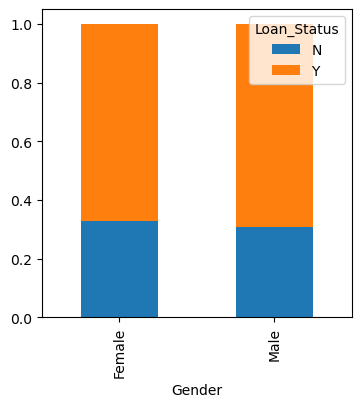

In [19]:
#Checking the loan status with all tge objects i.e., gender, married, etc

Gender=pd.crosstab(train['Gender'],train['Loan_Status'])
Gender.div(Gender.sum(1).astype(float), axis=0).plot(kind="bar", stacked =True, figsize=(4,4))
plt.show()

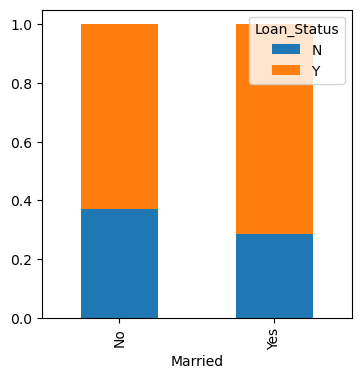

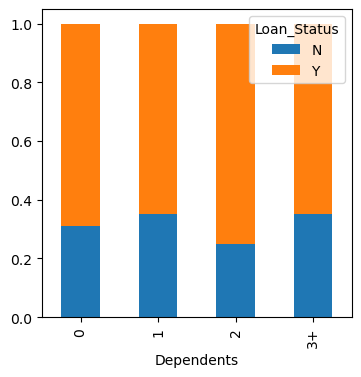

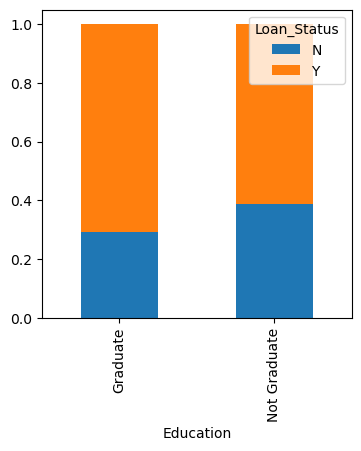

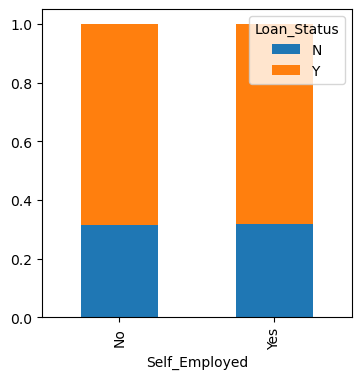

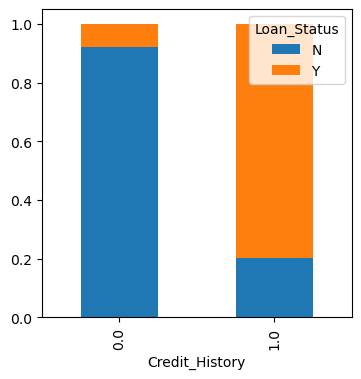

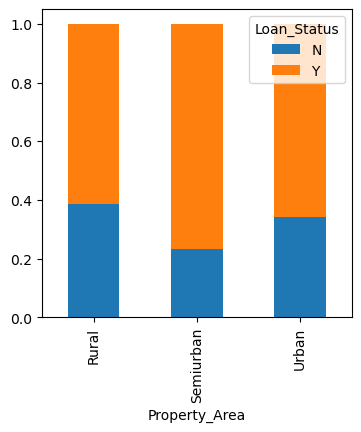

In [20]:

Married=pd.crosstab(train['Married'],train['Loan_Status'])
Married.div(Married.sum(1).astype(float), axis=0).plot(kind="bar", stacked =True, figsize=(4,4))
plt.show()

Dependents=pd.crosstab(train['Dependents'],train['Loan_Status'])
Dependents.div(Dependents.sum(1).astype(float), axis=0).plot(kind="bar", stacked =True, figsize=(4,4))
plt.show()

Education=pd.crosstab(train['Education'],train['Loan_Status'])
Education.div(Education.sum(1).astype(float), axis=0).plot(kind="bar", stacked =True, figsize=(4,4))
plt.show()

Self_Employed=pd.crosstab(train['Self_Employed'],train['Loan_Status'])
Self_Employed.div(Self_Employed.sum(1).astype(float), axis=0).plot(kind="bar", stacked =True, figsize=(4,4))
plt.show()

Credit_History=pd.crosstab(train['Credit_History'],train['Loan_Status'])
Credit_History.div(Credit_History.sum(1).astype(float), axis=0).plot(kind="bar", stacked =True, figsize=(4,4))
plt.show()

Property_Area=pd.crosstab(train['Property_Area'],train['Loan_Status'])
Property_Area.div(Property_Area.sum(1).astype(float), axis=0).plot(kind="bar", stacked =True, figsize=(4,4))
plt.show()

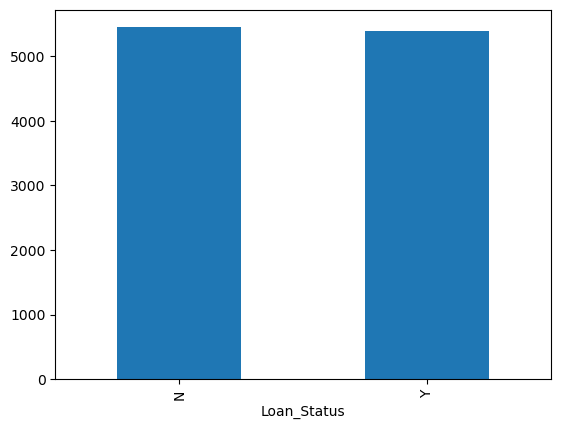

In [21]:
train.groupby('Loan_Status')['ApplicantIncome'].mean().plot.bar()
plt.show()

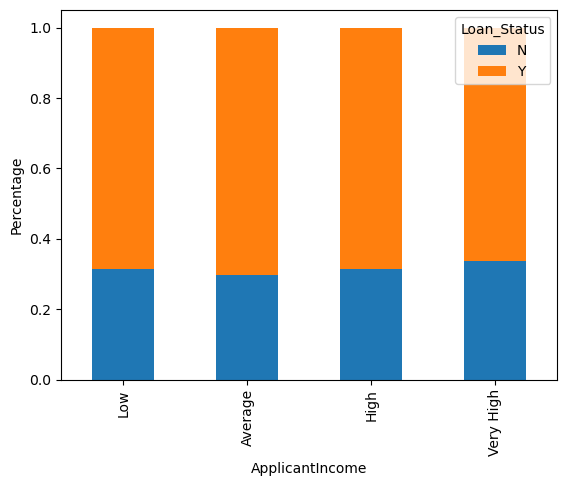

In [22]:
bins=[0,2500,4000,6000,81000]
group=['Low','Average','High','Very High']
train['Income_bin']=pd.cut(train['ApplicantIncome'],bins,labels=group)
Income_bin=pd.crosstab(train['Income_bin'],train['Loan_Status'])
Income_bin.div(Income_bin.sum(1).astype(float),axis=0).plot(kind="bar", stacked=True)
plt.xlabel('ApplicantIncome')
plt.ylabel('Percentage')
plt.show()

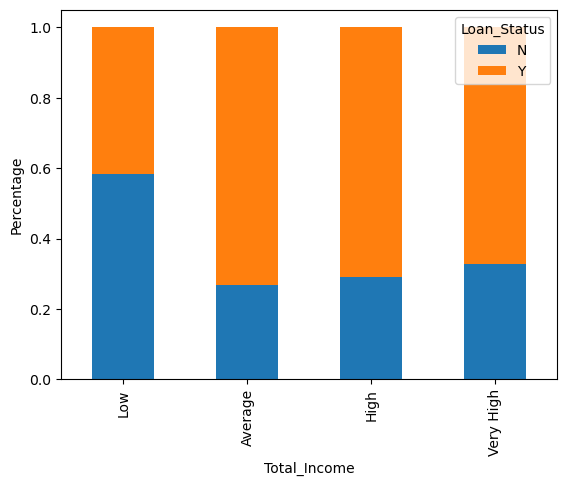

In [23]:
train['Total_Income']=train['ApplicantIncome']+train['CoapplicantIncome']
bins=[0,2500,4000,6000,81000]
group=['Low','Average','High','Very High']
train['Total_Income_bin']=pd.cut(train['Total_Income'],bins,labels=group)
Total_Income_bin=pd.crosstab(train['Total_Income_bin'],train['Loan_Status'])
Total_Income_bin.div(Total_Income_bin.sum(1).astype(float),axis=0).plot(kind="bar", stacked=True)
plt.xlabel('Total_Income')
plt.ylabel('Percentage')
plt.show()

In [43]:
train['Dependents'].replace('3+', 3,inplace=True)
test['Dependents'].replace('3+', 3,inplace=True)
#train['Loan_Status'].replace('N', 0,inplace=True)
#train['Loan_Status'].replace('Y', 1,inplace=True)
train['Gender'].replace('Male', 0,inplace=True)
train['Gender'].replace('Female', 1,inplace=True)

In [25]:
#Imputation starts here
train.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
Income_bin            0
Total_Income          0
Total_Income_bin      0
dtype: int64

In [26]:
train['Gender'].fillna(train['Gender'].mode()[0],inplace=True)
train['Married'].fillna(train['Married'].mode()[0],inplace=True)
train['Dependents'].fillna(train['Dependents'].mode()[0],inplace=True)
train['Self_Employed'].fillna(train['Self_Employed'].mode()[0],inplace=True)
train['Credit_History'].fillna(train['Credit_History'].mode()[0],inplace=True)

In [27]:
train.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History        0
Property_Area         0
Loan_Status           0
Income_bin            0
Total_Income          0
Total_Income_bin      0
dtype: int64

In [28]:
train['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [29]:
train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0],inplace=True)

In [30]:
train['LoanAmount'].fillna(train['LoanAmount'].median(),inplace=True)

In [44]:
train.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
Income_bin           0
Total_Income         0
Total_Income_bin     0
dtype: int64

In [32]:
test.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [33]:
test['Gender'].fillna(test['Gender'].mode()[0],inplace=True)
test['Dependents'].fillna(test['Dependents'].mode()[0],inplace=True)
test['Self_Employed'].fillna(test['Self_Employed'].mode()[0],inplace=True)
test['Credit_History'].fillna(test['Credit_History'].mode()[0],inplace=True)
test['Loan_Amount_Term'].fillna(test['Loan_Amount_Term'].mode()[0],inplace=True)
test['LoanAmount'].fillna(test['LoanAmount'].median(),inplace=True)

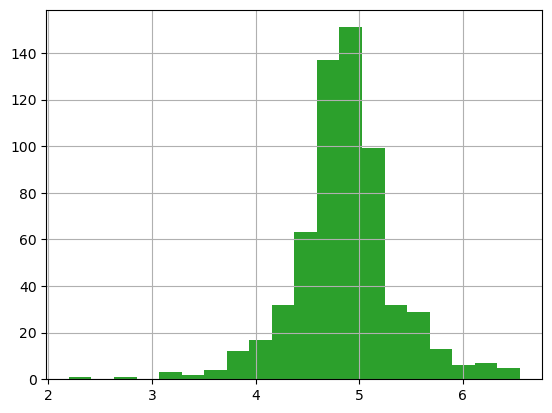

In [48]:
train['LoamAmount_log'] = np.log(train['LoanAmount'])
train['LoamAmount_log'].hist(bins=20)
train['LoamAmount_log'] = np.log(train['LoamAmount_log'])
plt.show()

In [34]:
test.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

In [35]:
train=train.drop('Loan_ID',axis=1)
test=test.drop('Loan_ID',axis=1)

In [49]:
X = train.drop('Loan_Status', axis=1)
y = train.Loan_Status

In [52]:
X=pd.get_dummies(X)
train=pd.get_dummies(train)
test=pd.get_dummies(test)

In [38]:
train['Loan_Status'].value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

In [71]:
#modelling

from sklearn.model_selection import train_test_split
x_train, x_cv, y_train, y_cv = train_test_split(X,y, test_size=0.3)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model=LogisticRegression()
model.fit(x_train, y_train)
LogisticRegression()
#LogisticRegression(C=1.0,class_weight=None, dual=False, fit_intercept=True, intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1, penalty='12', random_state=1, solver='liblinear', tol=0.0001, verbose=0, warm_start=False)

C:\Users\shafaat hussain\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [72]:
pred_cv=model.predict(x_cv)
accuracy_score(y_cv,pred_cv)

0.7513513513513513

In [76]:
import numpy as np
import pandas as pd

# assume `X` is your final training DataFrame used for model.fit (one-hot encoded)
# and `test` is your raw test DataFrame

# 1. build test_proc same way you built X (get_dummies + align)
test_proc = pd.get_dummies(test, drop_first=True)
missing_in_test = set(X.columns) - set(test_proc.columns)
extra_in_test   = set(test_proc.columns) - set(X.columns)

print("Train feature count:", len(X.columns))
print("Test (after get_dummies) feature count:", len(test_proc.columns))
print("Sample of missing features in test (expected by model):", list(missing_in_test)[:20])
print("Sample of extra features in test (not seen during training):", list(extra_in_test)[:20])

# 2. Reindex to exactly match train features (this is safe -- fills missing dummies with 0)
test_proc = test_proc.reindex(columns=X.columns, fill_value=0)

# 3. Quick sanity checks
print("\nAny all-zero rows in test_proc? ->", (test_proc.sum(axis=1) == 0).sum(), "rows")
print("Total non-zero values in test_proc:", (test_proc.values != 0).sum())
print("Per-column non-zero counts (first 20):")
print(test_proc.astype(bool).sum().sort_values(ascending=False).head(20))

# 4. Check model behavior on CV (shouldn't be all one class)
try:
    from sklearn.metrics import classification_report
    y_cv_pred = model.predict(x_cv)
    print("\nCV predictions distribution:", np.bincount(y_cv_pred.astype(int)))
    print("CV classification report:\n", classification_report(y_cv, y_cv_pred))
except Exception as e:
    print("Couldn't evaluate on x_cv/y_cv:", e)

# 5. Check probability distribution on test (will help see if model gives low probs)
try:
    probs = model.predict_proba(test_proc)
    pos_probs = probs[:,1]
    print("\nTest predicted positive-probability stats: mean={:.4f}, min={:.4f}, max={:.4f}".format(
        pos_probs.mean(), pos_probs.min(), pos_probs.max()))
    print("Percent predicted positive at default 0.5 threshold:", (pos_probs > 0.5).mean())
except Exception as e:
    print("predict_proba failed:", e)

# save test_proc for later inspection if needed
_test_proc = test_proc.copy()
print("\nDiagnostic done.")

Train feature count: 29
Test (after get_dummies) feature count: 20
Sample of missing features in test (expected by model): ['Income_bin_Average', 'Income_bin_Low', 'Total_Income_bin_High', 'Total_Income_bin_Average', 'Income_bin_High', 'Total_Income', 'LoamAmount_log', 'Income_bin_Very High', 'Total_Income_bin_Low', 'Total_Income_bin_Very High', 'Gender']
Sample of extra features in test (not seen during training): ['Gender_Male', 'Gender_Female']

Any all-zero rows in test_proc? -> 0 rows
Total non-zero values in test_proc: 3453
Per-column non-zero counts (first 20):
LoanAmount                  367
Loan_Amount_Term            367
ApplicantIncome             365
Self_Employed_No            330
Credit_History              308
Education_Graduate          283
Married_Yes                 233
CoapplicantIncome           211
Dependents_0                210
Property_Area_Urban         140
Married_No                  134
Property_Area_Semiurban     116
Property_Area_Rural         111
Education

In [78]:
# Ensure test is processed like train, then predict
test_proc = pd.get_dummies(test, drop_first=True)
test_proc = test_proc.reindex(columns=X.columns, fill_value=0)

# final predict
pred_test = model.predict(test_proc)

# if you want probabilities too:
probs_test = model.predict_proba(test_proc)[:,1]

# map back to Y/N if your submission needs that
submission['Loan_Status'] = np.where(pred_test==1, 'Y', 'N')
submission.to_csv('submission.csv', index=False)
#pred_test = model.predict(test)

In [79]:
submission = pd.read_csv(r"C:\Users\shafaat hussain\Desktop\aiml\Loan Prediction\Sample Submission.csv")

In [80]:
submission['Loan_Status'].replace(0, 'N',inplace=True)
submission['Loan_Status'].replace(1, 'Y',inplace=True)

In [81]:
pd.DataFrame(submission, columns=['Loan_ID','Loan_Status']).to_csv('logistic.csv')